# 09 — Projeção de Impacto Financeiro (ROI de Retenção)

**Objetivo:** Quantificar o valor econômico esperado das ações de retenção habilitadas pelo modelo,
aplicando o score de risco (output do `08_score`) à população ativa de Set–Dez/2025.

## Lógica do cálculo

```
Alertados(A+M)       = colaboradores classificados como Alto ou Médio no mês
Verdadeiros em risco = Alertados(A+M) × Precision(A+M)   ← estimada via validação
Pessoas retidas      = Verdadeiros_em_risco × Taxa_retenção  ← premissa da intervenção
Custo evitado        = Pessoas_retidas × vl_salario_mensal × 4
```

O **multiplicador 4×** representa uma estimativa simplificada do custo total de reposição de
um colaborador: recrutamento, onboarding, produtividade reduzida durante adaptação e perda de
conhecimento.

> ⚠️ **Simplificação:** este multiplicador é apenas uma referência para demonstrar a estrutura
> do cálculo. **Deve ser substituído por um levantamento real e interno** conduzido pelo time de
> RH/Controladoria. Benchmarks externos estimam custos de reposição entre 1.5–3× o salário
> anual (18–36× o mensal) para cargos operacionais.

## Premissas de precisão (Precision A+M da validação)

| Grupo | Precision Alto+Médio | Recall Alto+Médio |
|---|---:|---:|
| Vendas | 28.1% | 50.2% |
| Transporte | 26.5% | 51.6% |
| Fábrica | 32.5% | 63.9% |

## Premissas de taxa de retenção

A taxa de retenção é **a fração das pessoas verdadeiramente em risco que efetivamente não saem**
após a intervenção de RH. Três cenários são avaliados:

| Cenário | Taxa de retenção | Interpretação |
|---|---:|---|
| Conservador | 20% | Intervenções básicas (conversa com gestor) |
| Moderado | 35% | Intervenções combinadas (cargo + salário) |
| Otimista | 50% | Programa estruturado de retenção |

---

| Entrada | Arquivo |
|---|---|
| Score consolidado | `reports/score_risco_consolidado.parquet` |
| Base de aplicação (salários) | `data/gold/base_features_apl.parquet` |

| Saída | Arquivo |
|---|---|
| ROI detalhado por grupo × mês | `reports/roi_projecao.parquet` |
| ROI detalhado CSV | `reports/roi_projecao.csv` |
| Figura — ROI por cenário | `reports/figures/roi_por_cenario.png` |
| Figura — Alertados × Estimativa retidos | `reports/figures/roi_alertados_retidos.png` |
| Figura — Economia acumulada total | `reports/figures/roi_acumulado_total.png` |

## 1 · Setup & Configuração

In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-04-14 14:38


In [12]:

# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SCORE_PATH = REPORTS_DIR / "score_risco_consolidado.parquet"
APL_PATH   = PROJECT_ROOT / "data" / "gold" / "base_features_apl.parquet"

COL_ID    = "id_colaborador"
COL_GRUPO = "ds_grupo"
COL_DATA  = "dt_mes_ano"
COL_SAL   = "vl_salario"
GRUPOS    = ["Vendas", "Transporte", "Fábrica"]

# ── Precision Alto+Médio estimada via validação ────────────────
PRECISION_AM = {
    "Vendas"     : 0.281,
    "Transporte" : 0.265,
    "Fábrica"    : 0.325,
}

# ── Multiplicador de custo de reposição (× salário MENSAL) ────
# SIMPLIFICAÇÃO: referência interna estimou 4× salário mensal.
# Este valor deve ser substituído por estudo próprio de custo de
# reposição quando disponível (recrutamento + onboarding + perda
# de produtividade + custo de adaptação do substituto).
MULT_REPOSICAO = 4   # × salário mensal

# ── Cenários de taxa de retenção ──────────────────────────────
CENARIOS = {
    "Conservador (20%)" : 0.20,
    "Moderado (35%)"    : 0.35,
    "Otimista (50%)"    : 0.50,
}

CORES_CENARIO = {
    "Conservador (20%)" : "#1f77b4",
    "Moderado (35%)"    : "#ff7f0e",
    "Otimista (50%)"    : "#2ca02c",
}

print(f"Score path : {SCORE_PATH}")
print(f"APL path   : {APL_PATH}")
print(f"Multiplicador reposição : {MULT_REPOSICAO}x salário mensal  (SIMPLIFICAÇÃO — substituir por estudo interno)")


Score path : g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\score_risco_consolidado.parquet
APL path   : g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\data\gold\base_features_apl.parquet
Multiplicador reposição : 4x salário mensal  (SIMPLIFICAÇÃO — substituir por estudo interno)


## 2 · Carga e junção das bases

In [13]:
# ── Carregar score consolidado ────────────────────────────────
df_score = pd.read_parquet(SCORE_PATH)
print(f"Score : {df_score.shape}  | meses: {sorted(df_score[COL_DATA].dt.strftime('%Y-%m').unique())}")

# ── Carregar salário da base de aplicação ─────────────────────
df_sal = (
    pd.read_parquet(APL_PATH, columns=[COL_ID, COL_DATA, COL_GRUPO, COL_SAL])
    .drop_duplicates(subset=[COL_ID, COL_DATA])
)
print(f"Salários : {df_sal.shape}  | nulos: {df_sal[COL_SAL].isna().sum()}")

# ── Juntar ────────────────────────────────────────────────────
df = df_score.merge(df_sal[[COL_ID, COL_DATA, COL_SAL]], on=[COL_ID, COL_DATA], how="left")
print(f"Após join : {df.shape}  | nulos salário: {df[COL_SAL].isna().sum()}")

# Preencher nulos de salário com mediana do grupo (caso existam)
if df[COL_SAL].isna().any():
    medians = df.groupby(COL_GRUPO)[COL_SAL].median()
    df[COL_SAL] = df.apply(
        lambda r: medians[r[COL_GRUPO]] if pd.isna(r[COL_SAL]) else r[COL_SAL], axis=1
    )
    print(f"  Nulos preenchidos com mediana por grupo.")

print("\nSalário bruto mensal por grupo (reais):")
print(df.groupby(COL_GRUPO)[COL_SAL].describe()[["count","mean","50%","min","max"]].round(0).to_string())

Score : (37644, 8)  | meses: ['2025-09', '2025-10', '2025-11', '2025-12']
Salários : (37644, 4)  | nulos: 0
Após join : (37644, 9)  | nulos salário: 0

Salário bruto mensal por grupo (reais):
              count    mean     50%    min      max
ds_grupo                                           
Fábrica      7243.0  3355.0  2984.0    0.0  30000.0
Transporte  17599.0  2137.0  1804.0  713.0  29399.0
Vendas      12802.0  2259.0  1655.0  713.0  70868.0


## 3 · Métricas de alertas por grupo × mês

In [14]:
# ── Calcular indicadores agregados por grupo × mês ───────────
registros = []

for grupo in GRUPOS:
    prec_am = PRECISION_AM[grupo]
    df_g    = df[df[COL_GRUPO] == grupo]

    for mes in sorted(df_g[COL_DATA].unique()):
        df_m       = df_g[df_g[COL_DATA] == mes]
        n_total    = len(df_m)
        n_alto     = (df_m["grupo_risco"] == "Alto").sum()
        n_medio    = (df_m["grupo_risco"] == "Médio").sum()
        n_am       = n_alto + n_medio

        # Verdadeiros em risco (estimativa via precision de validação)
        n_verdadeiros = round(n_am * prec_am)

        # Salário médio do segmento Alto+Médio
        sal_am  = df_m.loc[df_m["grupo_risco"].isin(["Alto", "Médio"]), COL_SAL]
        sal_med = sal_am.mean() if len(sal_am) > 0 else df_m[COL_SAL].mean()

        # Custo de reposição por pessoa (simplificação: 4× salário mensal)
        custo_reposicao = sal_med * MULT_REPOSICAO

        rec = {
            "mes"             : mes,
            "grupo"           : grupo,
            "n_total"         : n_total,
            "n_alto"          : int(n_alto),
            "n_medio"         : int(n_medio),
            "n_am"            : int(n_am),
            "pct_am"          : round(n_am / n_total, 4),
            "precision_am"    : prec_am,
            "n_verdadeiros"   : int(n_verdadeiros),
            "sal_med_am"      : round(sal_med, 2),
            "custo_reposicao" : round(custo_reposicao, 2),
        }

        # ROI por cenário de taxa de retenção
        for nome, taxa in CENARIOS.items():
            retidos   = round(n_verdadeiros * taxa)
            economia  = round(retidos * custo_reposicao, 2)
            rec[f"retidos_{nome}"]  = retidos
            rec[f"economia_{nome}"] = economia

        registros.append(rec)

df_roi = pd.DataFrame(registros)
print(f"Tabela ROI construída: {df_roi.shape}")

# ── Preview ────────────────────────────────────────────────────
cols_preview = ["mes", "grupo", "n_total", "n_am", "pct_am",
                "n_verdadeiros", "sal_med_am", "custo_reposicao"]
print("\nIndicadores base por grupo × mês:")
print(df_roi[cols_preview].to_string(index=False))

Tabela ROI construída: (12, 17)

Indicadores base por grupo × mês:
       mes      grupo  n_total  n_am  pct_am  n_verdadeiros  sal_med_am  custo_reposicao
2025-09-01     Vendas     3119   836  0.2680            235     2655.47         10621.87
2025-10-01     Vendas     3157   846  0.2680            238     2654.80         10619.22
2025-11-01     Vendas     3230   865  0.2678            243     2582.98         10331.91
2025-12-01     Vendas     3296   883  0.2679            248     2440.61          9762.43
2025-09-01 Transporte     4323  1237  0.2861            328     1993.27          7973.09
2025-10-01 Transporte     4367  1249  0.2860            331     1972.91          7891.63
2025-11-01 Transporte     4412  1262  0.2860            334     1950.44          7801.76
2025-12-01 Transporte     4497  1286  0.2860            341     2019.16          8076.63
2025-09-01    Fábrica     1771   547  0.3089            178     3597.87         14391.47
2025-10-01    Fábrica     1797   555  0.308

## 4 · Projeção de ROI — sumário por grupo e cenário

In [ ]:
# ── Sumário consolidado por grupo × cenário ───────────────────
print("=" * 72)
print("PROJEÇÃO DE ROI — Set–Dez/2025  (4 meses de aplicação)")
print("=" * 72)
print(f"Multiplicador custo reposição : {MULT_REPOSICAO}x salário mensal  (simplificação)")
print(f"Precision Alto+Médio          : por grupo (ver tabela header)")
print()

total_geral = {nome: 0 for nome in CENARIOS}

for grupo in GRUPOS:
    dg = df_roi[df_roi["grupo"] == grupo]
    prec = PRECISION_AM[grupo]
    n_am_total       = dg["n_am"].sum()
    n_verdad_total   = dg["n_verdadeiros"].sum()
    sal_med          = dg["sal_med_am"].mean()
    custo_rep        = dg["custo_reposicao"].mean()

    print(f"{'─'*72}")
    print(f"  {grupo}")
    print(f"  Alertados A+M (4 meses)   : {n_am_total:,.0f}  "
          f"({dg['pct_am'].mean()*100:.1f}% da pop. média/mês)")
    print(f"  Precision A+M (val)       : {prec*100:.1f}%")
    print(f"  Verdadeiros em risco (est): {n_verdad_total:,.0f}")
    print(f"  Salário médio A+M         : R$ {sal_med:,.0f}/mês")
    print(f"  Custo reposição médio/pes : R$ {custo_rep:,.0f}  ({MULT_REPOSICAO}× sal. mensal — simplificação)")
    print()

    for nome, taxa in CENARIOS.items():
        retidos   = dg[f"retidos_{nome}"].sum()
        economia  = dg[f"economia_{nome}"].sum()
        total_geral[nome] += economia
        print(f"  {nome:<22}  retidos={retidos:>4,}  "
              f"economia=R$ {economia:>14,.0f}")
    print()

print("=" * 72)
print("  TOTAL GERAL (todos os grupos, 4 meses)")
print("=" * 72)
for nome, total in total_geral.items():
    print(f"  {nome:<22}  R$ {total:>16,.0f}")
print()

PROJEÇÃO DE ROI — Set–Dez/2025  (4 meses de aplicação)
Multiplicador custo reposição : 4x salário anual
Precision Alto+Médio          : por grupo (ver tabela header)

────────────────────────────────────────────────────────────────────────
  Vendas
  Alertados A+M (4 meses)   : 3,430  (26.8% da pop. média/mês)
  Precision A+M (val)       : 28.1%
  Verdadeiros em risco (est): 964
  Salário médio A+M         : R$ 2,583/mês
  Custo reposição médio/pes : R$ 10,334  (4× sal. mensal — simplificação)

  Conservador (20%)       retidos= 194  economia=R$      2,003,335
  Moderado (35%)          retidos= 337  economia=R$      3,479,932
  Otimista (50%)          retidos= 483  economia=R$      4,988,102

────────────────────────────────────────────────────────────────────────
  Transporte
  Alertados A+M (4 meses)   : 5,034  (28.6% da pop. média/mês)
  Precision A+M (val)       : 26.5%
  Verdadeiros em risco (est): 1,334
  Salário médio A+M         : R$ 1,984/mês
  Custo reposição médio/pes : R$ 7

## 5 · Distribuição mensal — alertados e estimativa de retidos

In [6]:
print("Detalhe mensal por grupo:")
print()

for grupo in GRUPOS:
    dg = df_roi[df_roi["grupo"] == grupo].copy()
    dg["mes_str"] = dg["mes"].dt.strftime("%Y-%m")
    print(f"  {grupo}  (Precision A+M = {PRECISION_AM[grupo]*100:.1f}%)")
    print(f"  {'Mês':<8} {'Total':>6} {'Alto':>5} {'Médio':>5} "
          f"{'A+M':>5} {'%A+M':>6} {'Verdad':>7} "
          f"{'Ret(20%)':>9} {'Ret(35%)':>9} {'Ret(50%)':>9}")
    print(f"  {'─'*80}")
    for _, r in dg.iterrows():
        print(f"  {r['mes_str']:<8} {r['n_total']:>6,} {r['n_alto']:>5,} {r['n_medio']:>5,} "
              f"{r['n_am']:>5,} {r['pct_am']*100:>5.1f}% {r['n_verdadeiros']:>7,} "
              f"{r['retidos_Conservador (20%)']:>9,} "
              f"{r['retidos_Moderado (35%)']:>9,} "
              f"{r['retidos_Otimista (50%)']:>9,}")
    print()

Detalhe mensal por grupo:

  Vendas  (Precision A+M = 28.1%)
  Mês       Total  Alto Médio   A+M   %A+M  Verdad  Ret(20%)  Ret(35%)  Ret(50%)
  ────────────────────────────────────────────────────────────────────────────────
  2025-09   3,119   557   279   836  26.8%     235        47        82       118
  2025-10   3,157   564   282   846  26.8%     238        48        83       119
  2025-11   3,230   577   288   865  26.8%     243        49        85       122
  2025-12   3,296   589   294   883  26.8%     248        50        87       124

  Transporte  (Precision A+M = 26.5%)
  Mês       Total  Alto Médio   A+M   %A+M  Verdad  Ret(20%)  Ret(35%)  Ret(50%)
  ────────────────────────────────────────────────────────────────────────────────
  2025-09   4,323   824   413 1,237  28.6%     328        66       115       164
  2025-10   4,367   833   416 1,249  28.6%     331        66       116       166
  2025-11   4,412   841   421 1,262  28.6%     334        67       117       167
  202

## 6 · Visualizações

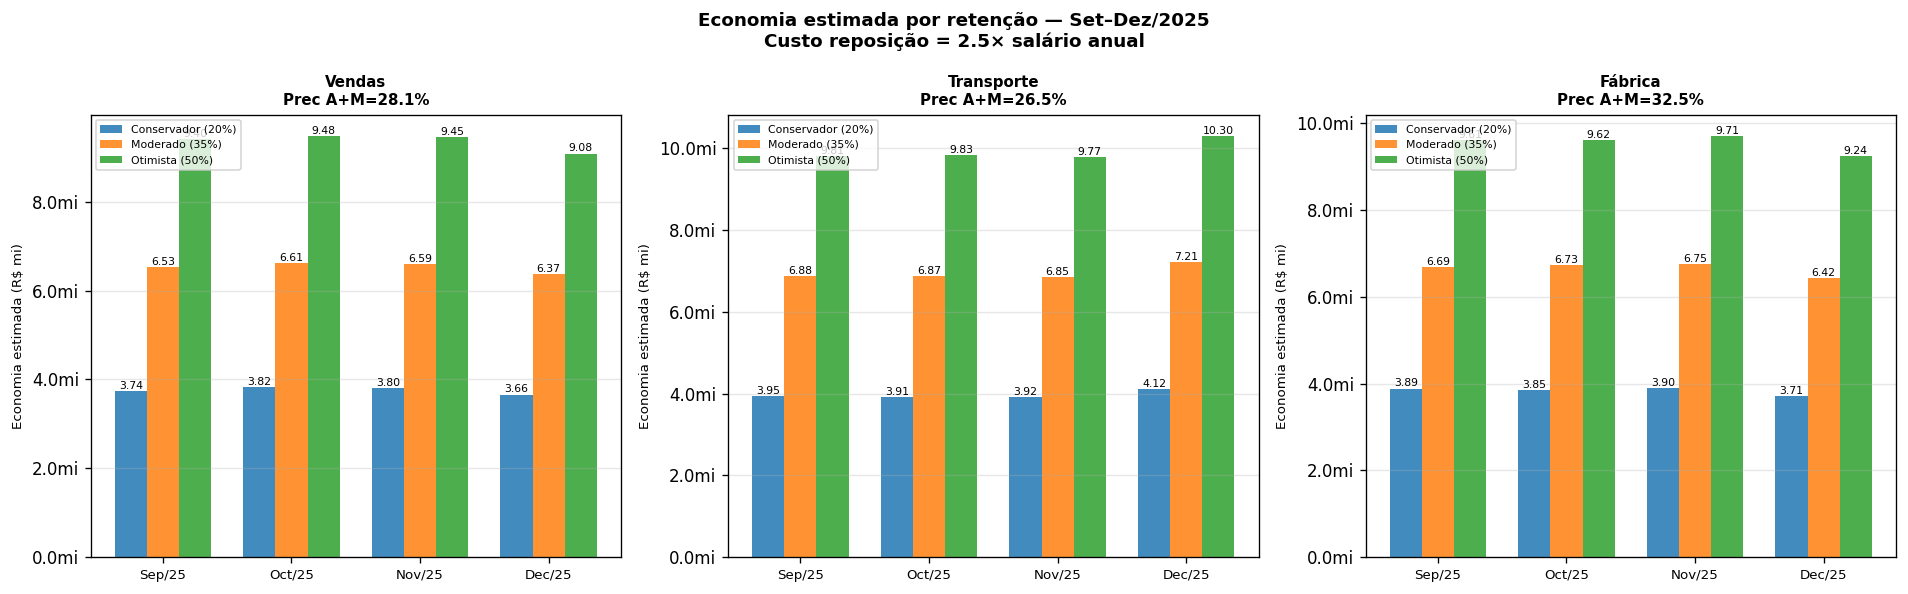

✓ g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\figures\roi_por_cenario.png


In [ ]:
# ── Plot 1: Economia acumulada por grupo × cenário ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, grupo in zip(axes, GRUPOS):
    dg = df_roi[df_roi["grupo"] == grupo].copy()
    dg["mes_str"] = dg["mes"].dt.strftime("%b/%y")

    x = range(len(dg))
    width = 0.25
    for i, (nome, taxa) in enumerate(CENARIOS.items()):
        vals = dg[f"economia_{nome}"] / 1e6   # em R$ mi
        bars = ax.bar([xi + i*width for xi in x], vals,
                      width=width, label=nome,
                      color=CORES_CENARIO[nome], alpha=0.85)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.003,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=6.5)

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(dg["mes_str"], fontsize=8)
    ax.set_title(f"{grupo}\nPrec A+M={PRECISION_AM[grupo]*100:.1f}%",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("Economia estimada (R$ mi)", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}mi"))
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=6.5, loc="upper left")

fig.suptitle(
    f"Economia estimada por retenção — Set–Dez/2025\n"
    f"Custo reposição = {MULT_REPOSICAO}× salário mensal (simplificação)",

    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig_path = FIGURES_DIR / "roi_por_cenario.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"✓ {fig_path}")

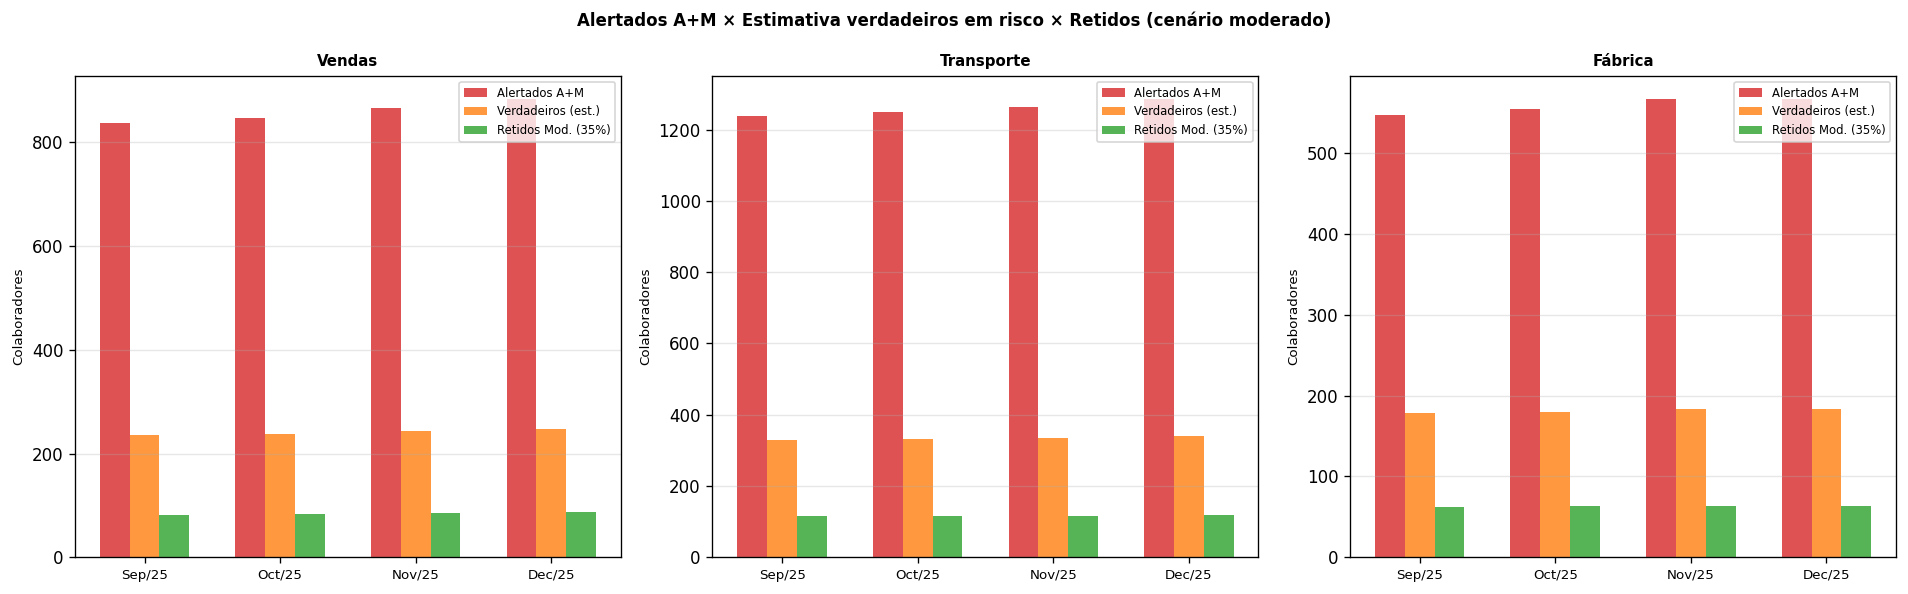

✓ g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\figures\roi_alertados_retidos.png


In [8]:
# ── Plot 2: Alertados vs Estimativa de verdadeiros vs Retidos ─
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, grupo in zip(axes, GRUPOS):
    dg = df_roi[df_roi["grupo"] == grupo].copy()
    dg["mes_str"] = dg["mes"].dt.strftime("%b/%y")
    x  = np.arange(len(dg))
    w  = 0.22

    b1 = ax.bar(x - w,      dg["n_am"],           width=w, label="Alertados A+M",         color="#d62728", alpha=0.8)
    b2 = ax.bar(x,          dg["n_verdadeiros"],   width=w, label="Verdadeiros (est.)",    color="#ff7f0e", alpha=0.8)
    b3 = ax.bar(x + w,      dg[f"retidos_Moderado (35%)"], width=w, label="Retidos Mod. (35%)", color="#2ca02c", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(dg["mes_str"], fontsize=8)
    ax.set_title(f"{grupo}", fontsize=9, fontweight="bold")
    ax.set_ylabel("Colaboradores", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(
    "Alertados A+M × Estimativa verdadeiros em risco × Retidos (cenário moderado)",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
fig_path2 = FIGURES_DIR / "roi_alertados_retidos.png"
plt.savefig(fig_path2, dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"✓ {fig_path2}")

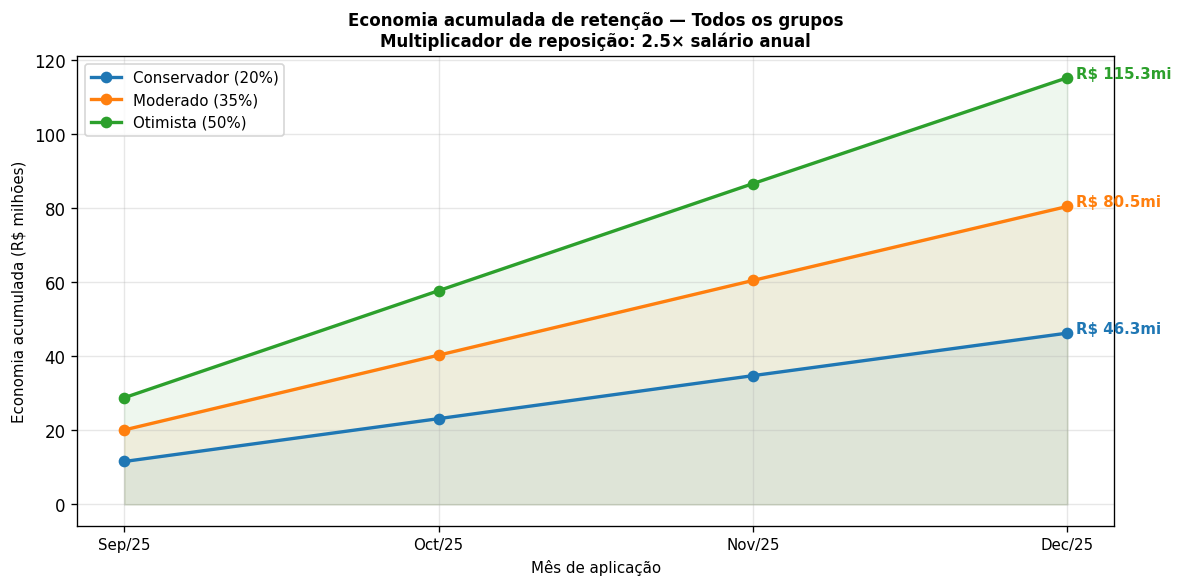

✓ g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\figures\roi_acumulado_total.png


In [ ]:
# ── Plot 3: Economia acumulada total (todos os grupos) ─────────
economia_acum = {}
for nome in CENARIOS:
    economia_acum[nome] = (
        df_roi.groupby("mes")[f"economia_{nome}"]
        .sum()
        .sort_index()
        .cumsum()
        / 1e6
    )

fig, ax = plt.subplots(figsize=(10, 5))
meses_str = [m.strftime("%b/%y") for m in sorted(df_roi["mes"].unique())]
x = np.arange(len(meses_str))

for nome, vals in economia_acum.items():
    ax.plot(x, vals.values, marker="o", lw=2,
            color=CORES_CENARIO[nome], label=nome)
    ax.fill_between(x, 0, vals.values, alpha=0.08, color=CORES_CENARIO[nome])
    # Anotação no ponto final
    ax.annotate(f"R$ {vals.values[-1]:.1f}mi",
                xy=(x[-1], vals.values[-1]),
                xytext=(5, 0), textcoords="offset points",
                fontsize=9, color=CORES_CENARIO[nome], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(meses_str, fontsize=9)
ax.set_ylabel("Economia acumulada (R$ milhões)", fontsize=9)
ax.set_xlabel("Mês de aplicação", fontsize=9)
ax.set_title(
    f"Economia acumulada de retenção — Todos os grupos\n"
    f"Custo reposição = {MULT_REPOSICAO}× salário mensal (simplificação)",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_acum = FIGURES_DIR / "roi_acumulado_total.png"
plt.savefig(fig_acum, dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"✓ {fig_acum}")

## 7 · Salvamento e sumário final

In [ ]:
# ── Salvar tabela ROI ─────────────────────────────────────────
out_parquet = REPORTS_DIR / "roi_projecao.parquet"
out_csv     = REPORTS_DIR / "roi_projecao.csv"
df_roi.to_parquet(out_parquet, index=False)
df_roi.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"✓ roi_projecao.parquet salvo  ({out_parquet})")
print(f"✓ roi_projecao.csv salvo")

# ── Sumário executivo ─────────────────────────────────────────
print()
print("=" * 65)
print("SUMÁRIO EXECUTIVO")
print("=" * 65)
n_am_total = df_roi["n_am"].sum()
n_verd     = df_roi["n_verdadeiros"].sum()
print(f"  Período de aplicação : Set–Dez/2025 (4 meses)")
print(f"  Total alertados A+M  : {n_am_total:,} colaborador×mês")
print(f"  Verdadeiros em risco (est.) : {n_verd:,}")
print()
for nome, taxa in CENARIOS.items():
    ret   = df_roi[f"retidos_{nome}"].sum()
    econ  = df_roi[f"economia_{nome}"].sum()
    print(f"  {nome:<22}  retidos={ret:>5,}  "
          f"economia total = R$ {econ:>14,.0f}  "
          f"({econ/1e6:.2f} mi)")
print()
print("  Premissas:")
print(f"  · Precision Alto+Médio  : Vendas={PRECISION_AM['Vendas']*100:.1f}%  "
      f"Transporte={PRECISION_AM['Transporte']*100:.1f}%  "
      f"Fábrica={PRECISION_AM['Fábrica']*100:.1f}%")
print(f"  · Custo reposição       : {MULT_REPOSICAO}x salário mensal  ⚠ simplificação — substituir por estudo interno")
print(f"  · Horizonte de predição : 4 meses")
print("="*65)
print("✅ 09_roi.ipynb concluído.")
print("="*65)

✓ roi_projecao.parquet salvo  (g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\roi_projecao.parquet)
✓ roi_projecao.csv salvo

SUMÁRIO EXECUTIVO
  Período de aplicação : Set–Dez/2025 (4 meses)
  Total alertados A+M  : 10,700 colaborador×mês
  Verdadeiros em risco (est.) : 3,024

  Conservador (20%)       retidos=  607  economia total = R$     46,269,160  (46.27 mi)
  Moderado (35%)          retidos=1,057  economia total = R$     80,499,453  (80.50 mi)
  Otimista (50%)          retidos=1,513  economia total = R$    115,280,373  (115.28 mi)

  Premissas:
  · Precision Alto+Médio  : Vendas=28.1%  Transporte=26.5%  Fábrica=32.5%
  · Custo reposição       : 2.5x salário anual
  · Horizonte de predição : 4 meses
✅ 09_roi.ipynb concluído.
